**RQ8: Which events generate the most media attention in German media outlets?**

Source: `locations_added.csv` and `documentidentifier_id.csv` 

We join both tables on `GKGRECORDID` to get per-document information about outlet, date, persons, locations, tone and a unique document identifier.

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


In [128]:
events_path = "Data/tagesschau_zdf_pbs_events.csv"
df = pd.read_csv(events_path)

display(df.head())
print(df.columns)


,SQLDATE,SOURCEURL,AvgTone,NumArticles,Actor1Name,Actor2Name,EventCode
0,20231008,https://www.kpbs.org/podcasts/kpbs-midday-edit...,-0.418098,10,UNITED STATES,VOTER,120
1,20231008,https://www.tagesschau.de/inland/debatte-hilfe...,-2.707930,10,POLITICIAN,NaN,138
2,20231008,https://www.tagesschau.de/ausland/asien/gaza-i...,-5.212121,6,ISRAELI,NaN,181
3,20231008,https://nhpbs.org/schedule/summary.aspx?progId...,2.867384,8,CALIFORNIA,NaN,120
4,20231008,https://www.pbs.org/newshour/nation/5-things-t...,2.768166,1,NATIVE PEOPLE,NaN,51


Index(['SQLDATE', 'SOURCEURL', 'AvgTone', 'NumArticles', 'Actor1Name',
       'Actor2Name', 'EventCode'],
      dtype='object')


In [129]:
GERMAN_DOMAINS = ["tagesschau.de", "zdf.de", "bild.de"]
pattern = "|".join(GERMAN_DOMAINS)

df_de = df[df["SOURCEURL"].str.contains(pattern, na=False)].copy()

print(f"Alle Events: {len(df):,}")
print(f"Events in deutschen Medien: {len(df_de):,}")
display(df_de.head())


Alle Events: 56,981
Events in deutschen Medien: 13,037


,SQLDATE,SOURCEURL,AvgTone,NumArticles,Actor1Name,Actor2Name,EventCode
1,20231008,https://www.tagesschau.de/inland/debatte-hilfe...,-2.707930,10,POLITICIAN,NaN,138
2,20231008,https://www.tagesschau.de/ausland/asien/gaza-i...,-5.212121,6,ISRAELI,NaN,181
11,20231008,https://www.tagesschau.de/ausland/asien/gaza-i...,-5.212121,4,ISRAELI,ISRAEL,181
12,20231008,https://www.tagesschau.de/inland/regional/berl...,-6.902655,10,CHANCELLOR,ISRAELI,173
27,20231008,https://www.tagesschau.de/eilmeldung/gaza-isra...,-4.572098,4,ISRAELI,ISRAEL,181


In [130]:
df_de["SQLDATE"] = df_de["SQLDATE"].astype(str)
df_de["Datetime"] = pd.to_datetime(df_de["SQLDATE"], format="%Y%m%d", errors="coerce")
df_de["Date"] = df_de["Datetime"].dt.date

display(df_de[["SQLDATE", "Datetime", "Date"]].head())


,SQLDATE,Datetime,Date
1,20231008,2023-10-08,2023-10-08
2,20231008,2023-10-08,2023-10-08
11,20231008,2023-10-08,2023-10-08
12,20231008,2023-10-08,2023-10-08
27,20231008,2023-10-08,2023-10-08


In [131]:
event_stats = (
    df_de
    .groupby("EventCode", as_index=False)
    .agg(
        total_articles=("NumArticles", "sum"),   # Media attention
        num_event_rows=("NumArticles", "size"),  # Amount GDELT-Event rows
        avg_tone=("AvgTone", "mean")             # Avereage Tone
    )
    .sort_values("total_articles", ascending=False)
)

display(event_stats.head(15))


,EventCode,total_articles,num_event_rows,avg_tone
10,20,10238,1344,-2.673767
0,10,7734,1128,-3.339088
23,40,6042,820,-2.460181
31,51,6035,847,-2.071334
58,110,3989,526,-3.396872
101,190,3597,527,-5.046664
62,120,3491,465,-2.967516
92,173,3455,494,-5.385107
59,111,2935,415,-4.321903
21,36,2935,412,-2.596233


In [132]:
#Eventcode-Description Mapping needed in order to interpret the event codes in the top events
event_lookup = pd.read_csv(
    "Data/eventcodes.txt",          
    sep="\t",
    header=0,
    encoding="latin1"               
)

event_lookup = event_lookup.rename(
    columns={"CAMEOEVENTCODE": "EventCode", "EVENTDESCRIPTION": "EventDescription"}
)

event_lookup["EventCode"] = event_lookup["EventCode"].astype(str)

display(event_lookup.head(10))


,EventCode,EventDescription
0,01,MAKE PUBLIC STATEMENT
1,010,"Make statement, not specified below"
2,011,Decline comment
3,012,Make pessimistic comment
4,013,Make optimistic comment
5,014,Consider policy option
6,015,Acknowledge or claim responsibility
7,016,Deny responsibility
8,017,Engage in symbolic act
9,018,Make empathetic comment


In [133]:
TOP_K = 5  # top 5 most important Eventtypes
top_codes = top_events_labeled["EventCode"].astype(str).head(TOP_K).tolist()

# EventCode-Typen angleichen
df_de = df_de.copy()
df_de["EventCode"] = df_de["EventCode"].astype(str)
event_lookup["EventCode"] = event_lookup["EventCode"].astype(str)

examples = (
    df_de[df_de["EventCode"].isin(top_codes)]
    .merge(event_lookup, on="EventCode", how="left")
    [["EventCode", "EventDescription", "SOURCEURL", "AvgTone", "NumArticles"]]
    .drop_duplicates(subset=["EventCode", "SOURCEURL"])
    .sort_values(["EventCode"])
)

display(examples.head())


,EventCode,EventDescription,SOURCEURL,AvgTone,NumArticles
2287,10,DEMAND,https://www.tagesschau.de/investigativ/wdr/tel...,-4.127358,2
3657,10,DEMAND,https://www.tagesschau.de/ausland/asien/gaza-h...,-2.371542,10
3655,10,DEMAND,https://www.tagesschau.de/ausland/asien/gazast...,-7.107232,10
1074,10,DEMAND,https://www.tagesschau.de/newsticker/liveblog-...,-1.848739,6
1075,10,DEMAND,https://www.tagesschau.de/ausland/europa/strac...,0.270270,10


In [134]:
event_stats["EventCode"] = event_stats["EventCode"].astype(str)

event_stats_labeled = (
    event_stats
    .merge(event_lookup, on="EventCode", how="left")
    .sort_values("total_articles", ascending=False)
)

display(event_stats_labeled.head(15))


,EventCode,total_articles,num_event_rows,avg_tone,EventDescription
0,20,10238,1344,-2.673767,USE UNCONVENTIONAL MASS VIOLENCE
1,10,7734,1128,-3.339088,DEMAND
2,40,6042,820,-2.460181,NaN
3,51,6035,847,-2.071334,NaN
4,110,3989,526,-3.396872,"Disapprove, not specified below"
5,190,3597,527,-5.046664,"Use conventional military force, not specified..."
6,120,3491,465,-2.967516,"Reject, not specified below"
7,173,3455,494,-5.385107,"Arrest, detain, or charge with legal action"
8,111,2935,415,-4.321903,Criticize or denounce
9,36,2935,412,-2.596233,NaN


/var/folders/6j/66mw38ys7q7c59ns85qtzy280000gn/T/ipykernel_9198/3746788466.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


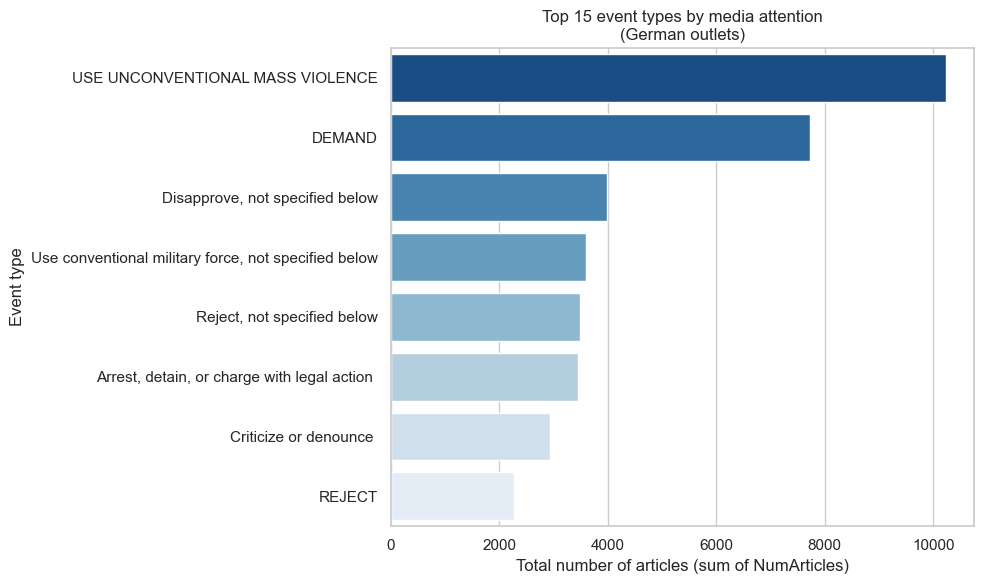

In [135]:
TOP_N = 15
top_events_labeled = event_stats_labeled.head(TOP_N).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_events_labeled,
    x="total_articles",
    y="EventDescription",
    palette="Blues_r"
)
plt.title(f"Top {TOP_N} event types by media attention\n(German outlets)")
plt.xlabel("Total number of articles (sum of NumArticles)")
plt.ylabel("Event type")
plt.tight_layout()
plt.show()


In [136]:
TOP_ACTORS = 5  # Top 5 actors per Eventtype

codes_focus = top_events_labeled["EventCode"].astype(str).tolist()

event_actor_sub = event_actor[event_actor["EventCode"].isin(codes_focus)].copy()

#rank per eventcode
event_actor_sub["rank"] = (
    event_actor_sub
    .groupby("EventCode")["total_articles"]
    .rank("dense", ascending=False)
)

event_actor_top = event_actor_sub[event_actor_sub["rank"] <= TOP_ACTORS].copy()


In [137]:
code_to_label = (
    event_actor_top[["EventCode", "EventDescription"]]
    .drop_duplicates()
    .set_index("EventCode")["EventDescription"]
    .to_dict()
)

event_actor_top["EventLabel"] = event_actor_top["EventCode"].map(code_to_label)


/var/folders/6j/66mw38ys7q7c59ns85qtzy280000gn/T/ipykernel_9198/534773691.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


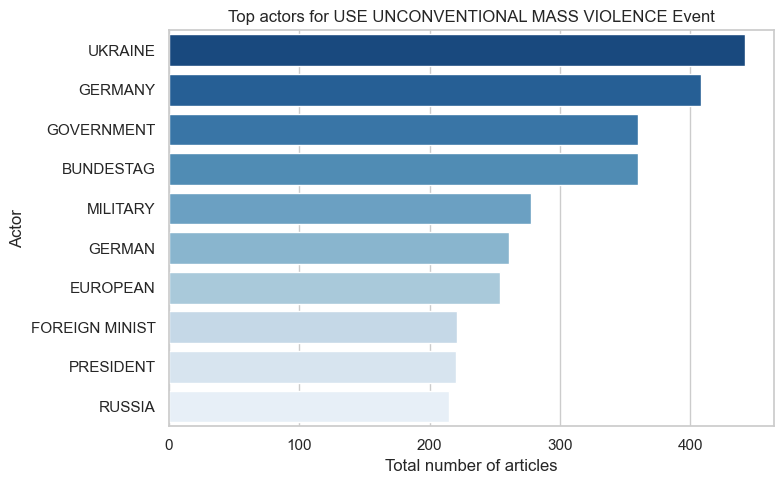

In [138]:
subset_20 = df_20[df_20["EventCode"] == code_focus].copy()

subset_20["Actor1_or_2"] = subset_20["Actor1Name"].fillna(subset_20["Actor2Name"])

actors_20 = (
    subset_20
    .groupby("Actor1_or_2", as_index=False)
    .agg(total_articles=("NumArticles", "sum"))
    .sort_values("total_articles", ascending=False)
)

TOP_ACTORS_20 = 10
actors_20_top = actors_20.head(TOP_ACTORS_20).copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=actors_20_top,
    x="total_articles",
    y="Actor1_or_2",
    palette="Blues_r"
)
plt.title("Top actors for USE UNCONVENTIONAL MASS VIOLENCE Event")
plt.xlabel("Total number of articles")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()
